In [63]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import umap
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

import geopandas


In [36]:
#read in incidence data, keep FIPS as string to avoid leading zeros being dropped
incd = pd.read_csv('cancer_incidence_data_2023/cleaned_state_cancer_incd_data.csv', dtype={'FIPS': str})
incd.head()

,County,FIPS,Rural_Urban_Code,Age_Adjusted_Incd_Rate,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,"Union County, Florida(2)",12125,Rural,1215.0,1144.9,1288.5,237,stable,0.3,-0.6,1.2
1,"Polk County, Texas(7)",48373,Rural,683.8,651.9,716.9,440,stable,-1.7,-3.9,0.8
2,"McPherson County, Nebraska(2)",31117,Rural,677.0,377.1,1145.8,4,*,*,*,*
3,"Dewey County, South Dakota(2)",46041,Rural,649.8,543.8,769.7,29,stable,1.4,-0.5,3.4
4,"Bracken County, Kentucky(7)",21023,Urban,621.8,555,695,68,stable,0.7,-0.6,2.1


In [37]:
#read in socioeconomic data
employment = pd.read_csv('USDA_economic_research_data/unemployment_2000s_cleaned.csv', dtype={'FIPS_Code': str})
edu = pd.read_csv('USDA_economic_research_data/education_2000s_cleaned.csv', dtype={'FIPS Code': str})

In [38]:
print(incd.shape)
print(employment.shape)
print(edu.shape)

(3143, 11)
(3269, 4)
(3267, 13)


In [39]:
#FIPS Code -> FIPS for the socioeconomic data
employment = employment.rename(columns={'FIPS_Code': 'FIPS'})
edu = edu.rename(columns={'FIPS Code': 'FIPS'})
#woops think theres a space in the incd FIPS column, so rename that too
incd = incd.rename(columns={'FIPS ': 'FIPS'})


In [40]:
#join on FIPS

joined = incd.merge(employment, on="FIPS", how="inner")
joined = joined.merge(edu, on="FIPS", how="inner")


In [24]:
joined.head()

,County,FIPS,Rural_Urban_Code,Age_Adjusted_Incd_Rate,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,...,Decade_y,Year,Percent of adults completing some college or associate degree,Percent of adults completing some college or associate degree-12,Percent of adults who are high school graduates (or equivalent),Percent of adults who are high school graduates (or equivalent)-12,Percent of adults who are not high school graduates,Percent of adults who are not high school graduates-12,Percent of adults with a bachelor's degree or higher,Percent of adults with a bachelor's degree or higher-12
0,"Union County, Florida(2)",12125,Rural,1215.0,1144.9,1288.5,237,stable,0.3,-0.6,...,2000,2004.0,26.1,26.484102,38.9,38.200698,27.5,25.170006,7.5,10.145194
1,"Polk County, Texas(7)",48373,Rural,683.8,651.9,716.9,440,stable,-1.7,-3.9,...,2000,2004.0,23.1,29.941824,36.5,35.174527,30.0,22.858646,10.4,12.025003
2,"McPherson County, Nebraska(2)",31117,Rural,677.0,377.1,1145.8,4,*,*,*,...,2000,2004.0,26.7,42.105263,39.7,26.315789,11.4,6.666667,22.2,24.912281
3,"Dewey County, South Dakota(2)",46041,Rural,649.8,543.8,769.7,29,stable,1.4,-0.5,...,2000,2004.0,33.1,31.493397,32.2,36.302066,22.6,17.947850,12.2,14.256688
4,"Bracken County, Kentucky(7)",21023,Urban,621.8,555,695,68,stable,0.7,-0.6,...,2000,2004.0,19.5,22.742594,40.6,40.039028,30.4,22.334575,9.5,14.883803


In [26]:
joined.isna().sum()

County                                                                  0
FIPS                                                                    0
Rural_Urban_Code                                                        0
Age_Adjusted_Incd_Rate                                                113
Lower 95% Confidence Interval                                           0
Upper 95% Confidence Interval                                           0
Average Annual Count                                                    0
Recent Trend                                                            0
Recent 5-Year Trend ([trend note]) in Incidence Rates                   0
Lower 95% Confidence Interval.1                                         0
Upper 95% Confidence Interval.1                                         0
State_x                                                                 0
Decade_x                                                                0
Unemployment_rate_                    

In [41]:
#looks like we have 113 counties without incidence data, so let's drop those
joined.dropna(subset=['Age_Adjusted_Incd_Rate'], inplace=True)

In [42]:
print(joined.shape)
joined.isna().sum()


(3022, 26)


County                                                                0
FIPS                                                                  0
Rural_Urban_Code                                                      0
Age_Adjusted_Incd_Rate                                                0
Lower 95% Confidence Interval                                         0
Upper 95% Confidence Interval                                         0
Average Annual Count                                                  0
Recent Trend                                                          0
Recent 5-Year Trend ([trend note]) in Incidence Rates                 0
Lower 95% Confidence Interval.1                                       0
Upper 95% Confidence Interval.1                                       0
State_x                                                               0
Decade_x                                                              0
Unemployment_rate_                                              

In [44]:
joined.drop(columns=['Recent Trend', 'State_x', 'State_y', 'Decade_x', 'Decade_y', 'Year', 'Area name', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'Lower 95% Confidence Interval.1', 'Upper 95% Confidence Interval.1'], inplace=True)

In [45]:
#to run PCA, features must be numeric, so lets check all the data types
joined.dtypes

County                                                                 object
FIPS                                                                   object
Rural_Urban_Code                                                       object
Age_Adjusted_Incd_Rate                                                float64
Average Annual Count                                                   object
Recent 5-Year Trend ([trend note]) in Incidence Rates                  object
Unemployment_rate_                                                    float64
Percent of adults completing some college or associate degree         float64
Percent of adults completing some college or associate degree-12      float64
Percent of adults who are high school graduates (or equivalent)       float64
Percent of adults who are high school graduates (or equivalent)-12    float64
Percent of adults who are not high school graduates                   float64
Percent of adults who are not high school graduates-12          

In [46]:
#coerce the Average Annual Count and Recent 5-Year Trend to numberic
joined['Average Annual Count'] = pd.to_numeric(joined['Average Annual Count'], errors='coerce')
joined['Recent 5-Year Trend ([trend note]) in Incidence Rates'] = pd.to_numeric(joined['Recent 5-Year Trend ([trend note]) in Incidence Rates'], errors='coerce')


In [47]:
#lets also rename that Recent 5-Year Trend column to something shorter
joined = joined.rename(columns={'Recent 5-Year Trend ([trend note]) in Incidence Rates': 'Recent_5yr_Trend'})


In [48]:
joined.dtypes

County                                                                 object
FIPS                                                                   object
Rural_Urban_Code                                                       object
Age_Adjusted_Incd_Rate                                                float64
Average Annual Count                                                    int64
Recent_5yr_Trend                                                      float64
Unemployment_rate_                                                    float64
Percent of adults completing some college or associate degree         float64
Percent of adults completing some college or associate degree-12      float64
Percent of adults who are high school graduates (or equivalent)       float64
Percent of adults who are high school graduates (or equivalent)-12    float64
Percent of adults who are not high school graduates                   float64
Percent of adults who are not high school graduates-12          

In [69]:
joined.isna().sum()

Rural_Urban_Code                                                      0
Age_Adjusted_Incd_Rate                                                0
Average Annual Count                                                  0
Unemployment_rate_                                                    0
Percent of adults completing some college or associate degree         0
Percent of adults completing some college or associate degree-12      0
Percent of adults who are high school graduates (or equivalent)       0
Percent of adults who are high school graduates (or equivalent)-12    0
Percent of adults who are not high school graduates                   0
Percent of adults who are not high school graduates-12                0
Percent of adults with a bachelor's degree or higher                  0
Percent of adults with a bachelor's degree or higher-12               0
Cluster                                                               0
dtype: int64

In [89]:
#joined = joined.drop(columns="Recent_5yr_Trend",)
#joined = joined.drop(columns="County")
#joined = joined.drop(columns="Rural_Urban_Code")
joined = joined.drop('Average Annual Count', axis=1)


In [91]:
joined = joined.set_index('FIPS')

X = StandardScaler().fit_transform(joined)
km = KMeans(n_clusters=9, random_state=42, n_init=10)
joined['Cluster'] = km.fit_predict(X)


In [92]:
print(joined.head(20))

       Age_Adjusted_Incd_Rate  Unemployment_rate_  \
FIPS                                                
12125                  1215.0                3.75   
48373                   683.8                6.94   
31117                   677.0                2.19   
46041                   649.8                9.00   
21023                   621.8                6.24   
28119                   621.8                8.85   
48229                   618.8                6.04   
21237                   615.5                9.80   
27087                   608.7                6.11   
21057                   606.5                7.48   
27155                   606.0                4.78   
51640                   605.2                6.52   
46049                   604.7                3.01   
17003                   603.7                9.12   
13053                   601.3               10.37   
21139                   598.4                6.55   
21137                   598.0                7

In [ ]:
#need FIPS to merge with geospatial data, so reset index
joined = joined.reset_index()


/var/folders/ww/wjz8v5x15495rp9s2wy47qbw0000gn/T/ipykernel_43114/1587085110.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(n_clusters))


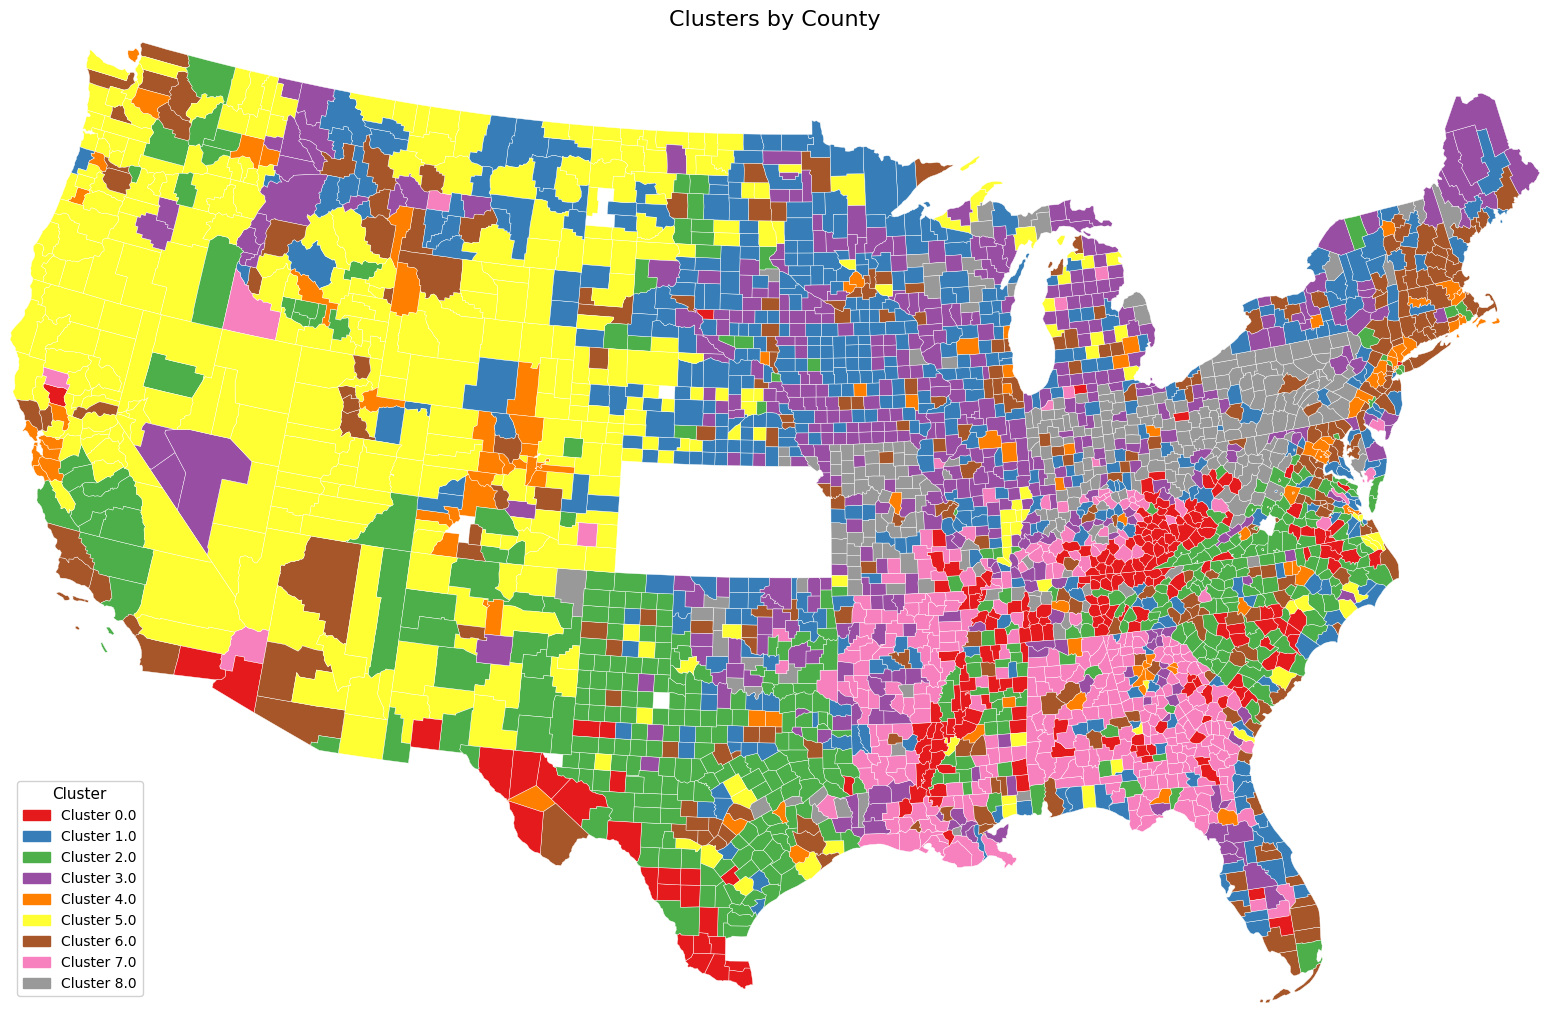

In [94]:
import matplotlib.patches as mpatches

# --- Fix 1: reproject FIRST before any plotting ---
gdf = geopandas.read_file('cancer_incidence_data_2023/cb_2018_us_county_20m/cb_2018_us_county_20m.shp')
gdf = gdf.rename(columns={'GEOID': 'FIPS'})
gdf = gdf.merge(joined[['FIPS', 'Cluster']], on='FIPS', how='left')
gdf = gdf.to_crs("EPSG:5070")  # reproject before anything else

conus = gdf[~gdf['STATEFP'].isin(['02', '15', '72'])]  # exclude AK, HI, PR
conus_bounds = conus.total_bounds

# --- Fix 2: make Cluster categorical ---
conus = conus.copy()
conus['Cluster'] = conus['Cluster'].astype('category')

n_clusters = conus['Cluster'].cat.categories
cmap = plt.cm.get_cmap('Set1', len(n_clusters))

fig = plt.figure(figsize=(18, 12))
ax_main = fig.add_axes([0.0, 0.1, 0.85, 0.85])

conus.plot(
    column='Cluster',
    ax=ax_main,
    cmap=cmap,
    legend=False,
    edgecolor='white',
    linewidth=0.3
)

ax_main.set_xlim(conus_bounds[[0, 2]])
ax_main.set_ylim(conus_bounds[[1, 3]])
ax_main.set_title('Clusters by County', fontsize=16, pad=12)
ax_main.set_axis_off()

# --- Fix 3: manual categorical legend instead of colorbar ---
patches = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {cat}')
    for i, cat in enumerate(n_clusters)
]
ax_main.legend(
    handles=patches,
    title='Cluster',
    loc='lower left',
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9
)

plt.show()

In [95]:
#what do the clusters look like in terms of feature profiles? 
#i.e. what are the mean feature values of each cluster?
#only the numeric columns- we can ignore the FIPS and Cluster columns
clust_means = joined.groupby('Cluster').mean(numeric_only=True) 
print(clust_means)    

         Age_Adjusted_Incd_Rate  Unemployment_rate_  \
Cluster                                               
0                    477.305195            8.425498   
1                    476.688377            4.725271   
2                    436.789607            6.015727   
3                    488.720870            5.920065   
4                    421.286087            4.372783   
5                    397.308101            5.577318   
6                    454.042667            4.634058   
7                    478.737126            6.498660   
8                    470.956507            6.148185   

         Percent of adults completing some college or associate degree  \
Cluster                                                                  
0                                                17.493074               
1                                                29.315431               
2                                                24.381755               
3                       

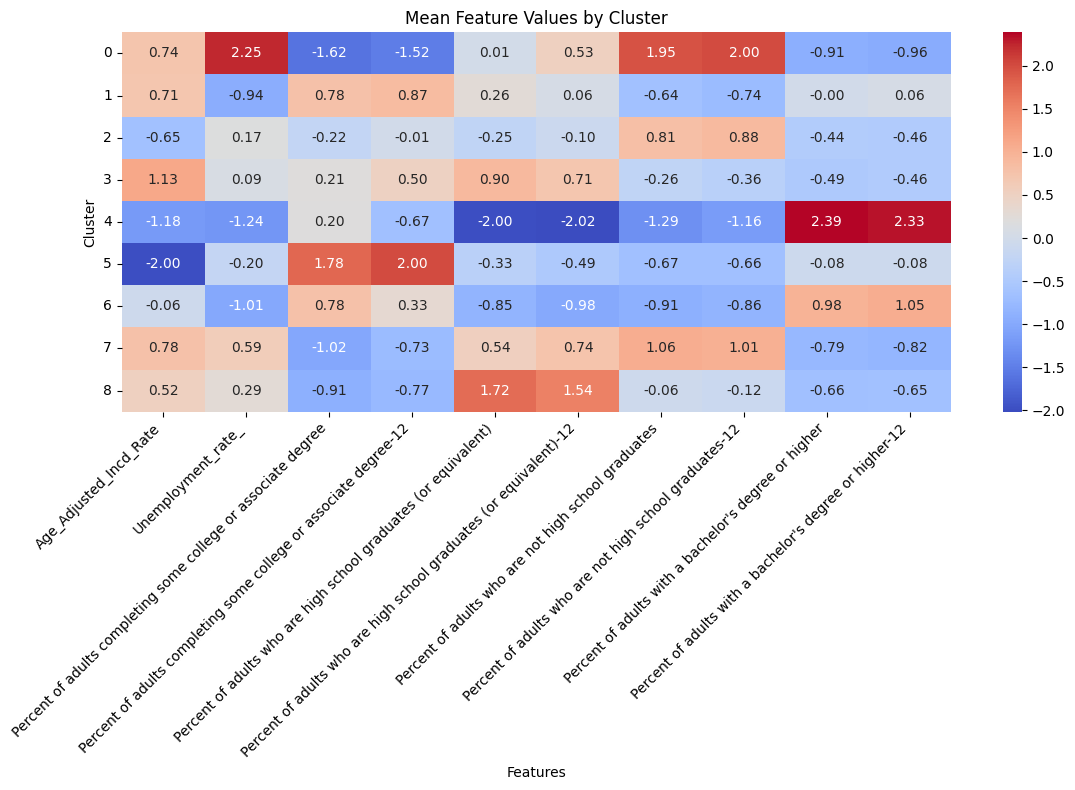

In [98]:
#scale clusters means for better visualization
clust_means_scaled = StandardScaler().fit_transform(clust_means)
clust_means_scaled_df = pd.DataFrame(clust_means_scaled, index=clust_means.index, columns=clust_means.columns)

#visualize the cluster profiles with a heatmap
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(clust_means_scaled_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mean Feature Values by Cluster')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
